# SPHINX Injection Analysis

This notebook has two separate stages for the SPHINX `G-DAE` branch:

1. **Preprocessing stage**: generate or update the decontaminated `*_recon.dat` spectra that will later be used by the MPI retrieval.
2. **Post-retrieval analysis stage**: after the corresponding MPI retrieval has already finished, load the saved POSEIDON products and compare the retrieved median spectrum against the clean reference spectrum.

Run the preprocessing block first if the reconstructed spectra do not exist yet. Run the analysis block only after the MPI retrievals have already been executed.

# SPHINX G-DAE workflow: preprocessing + analysis of completed retrievals


In [34]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Paths and selected analysis case
# -----------------------------
MODEL_PATH = Path("../Models/G-DAE.keras")
OBS_DIR = Path("../observations_sphinx")
BASELINE_OBS_DIR = Path("../observations")
CLEAN_PATH = Path("../pandexo_spec.txt")
COMMON_LOG_PATH = Path("chi2_log_sphinx.csv")
RETRIEVAL_STRATEGY = "gdae"

CASE_N_TRANSITS = 10
CASE_F_SPOT = 0.26
CASE_F_FAC = 0.70

OBSERVATION_FILE_RECON = (
    f"pandexo_output_{CASE_N_TRANSITS}transits_"
    f"sphinx_fspot{CASE_F_SPOT:.2f}_ffac{CASE_F_FAC:.2f}_recon.dat"
)
MODEL_NAME = (
    f"sphinx_recon_{CASE_N_TRANSITS}T_"
    f"{CASE_F_SPOT:.2f}spot-{CASE_F_FAC:.2f}fac"
)


# -----------------------------
# Reconstruction batch used before the MPI retrievals
# -----------------------------
RECONSTRUCTION_CASES: List[Dict[str, Path | str]] = [
    {
        "spec_name": "pandexo_output_10transits_fspot0.00_ffac0.00",
        "obs_dir": BASELINE_OBS_DIR,
        "save_dir": BASELINE_OBS_DIR,
    },
    {
        "spec_name": "pandexo_output_10transits_sphinx_fspot0.01_ffac0.08",
        "obs_dir": OBS_DIR,
        "save_dir": OBS_DIR,
    },
    {
        "spec_name": "pandexo_output_10transits_sphinx_fspot0.08_ffac0.54",
        "obs_dir": OBS_DIR,
        "save_dir": OBS_DIR,
    },
    {
        "spec_name": "pandexo_output_10transits_sphinx_fspot0.26_ffac0.70",
        "obs_dir": OBS_DIR,
        "save_dir": OBS_DIR,
    },
]


## Utilities

- `POSEIDON.instrument.bin_spectrum_to_data(...)` is used whenever a spectrum must be brought to the observed wavelength bins.
- The clean reference spectrum is sorted to ascending wavelength before any POSEIDON binning step.
- The remaining helpers handle scaling, IO, and array preparation for the autoencoder preprocessing stage.


In [22]:
def normalize_min_max(arr: np.ndarray) -> np.ndarray:
    """
    Sample-wise Min–Max normalization for a 1D array.

    Returns zeros if the dynamic range is zero.
    """
    arr = np.asarray(arr, dtype=np.float32)
    min_val = float(arr.min())
    max_val = float(arr.max())
    rng = max_val - min_val

    if rng == 0.0:
        return np.zeros_like(arr)

    return (arr - min_val) / rng


def inverse_min_max_1d(normed: np.ndarray, ref: np.ndarray) -> np.ndarray:
    """
    Invert Min–Max normalization using the min/max of a reference array.
    """
    normed = np.asarray(normed, dtype=np.float32)
    ref = np.asarray(ref, dtype=np.float32)

    min_ref = float(ref.min())
    max_ref = float(ref.max())

    return normed * (max_ref - min_ref) + min_ref


def load_spectrum(spec_name: str, obs_dir: Path = OBS_DIR) -> np.ndarray:
    """
    Load an observation file as an (N, 4) array: (wl, Δwl, rp2/rs2, err).
    """
    path = obs_dir / f"{spec_name}.dat"
    if not path.is_file():
        raise FileNotFoundError(f"Observation not found: {path}")

    arr = np.loadtxt(path)
    if arr.ndim != 2 or arr.shape[1] < 4:
        raise ValueError(f"Expected (N, 4)+ columns, got shape {arr.shape}")

    return arr[:, :4].astype(np.float32)


def split_spectrum_columns(
    spectrum: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Split spectrum columns into typed vectors: (wl, Δwl, noisy, err).
    """
    wl = spectrum[:, 0].astype(np.float32)
    d_wl = spectrum[:, 1].astype(np.float32)
    y_noisy = spectrum[:, 2].astype(np.float32)
    y_err = spectrum[:, 3].astype(np.float32)
    return wl, d_wl, y_noisy, y_err


def load_clean_spectrum(clean_path: Path = CLEAN_PATH) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load a clean spectrum with two columns: (wl, depth) and sort it by wavelength.

    Sorting is required here because ``pandexo_spec.txt`` is stored in descending
    wavelength order, while ``POSEIDON.instrument.bin_spectrum_to_data(...)``
    expects a monotonic wavelength grid.
    """
    if not clean_path.is_file():
        raise FileNotFoundError(f"Clean spectrum not found: {clean_path}")

    arr = np.loadtxt(clean_path)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"Expected at least 2 columns, got shape {arr.shape}")

    wl_clean = arr[:, 0].astype(np.float32)
    y_clean = arr[:, 1].astype(np.float32)

    sort_idx = np.argsort(wl_clean)
    return wl_clean[sort_idx], y_clean[sort_idx]


def force_reverse_order(
    wl: np.ndarray,
    d_wl: np.ndarray,
    y_noisy: np.ndarray,
    y_err: np.ndarray,
    y_clean_binned: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Reverse all vectors along axis 0. Use only if your files are known to be descending.
    """
    return (
        wl[::-1].copy(),
        d_wl[::-1].copy(),
        y_noisy[::-1].copy(),
        y_err[::-1].copy(),
        y_clean_binned[::-1].copy(),
    )


## Step A) Generate the decontaminated `*_recon.dat` spectra

Run this block **before** launching the MPI `G-DAE` retrievals if the reconstructed spectra are missing or need to be regenerated.

This is the only stage in the SPHINX `G-DAE` branch that applies the autoencoder and writes the decontaminated spectra to disk.


In [3]:
def load_autoencoder(model_path: Path = MODEL_PATH):
    """
    Load a Keras autoencoder from disk.

    Import is local to avoid requiring TensorFlow unless reconstruction is used.
    """
    from tensorflow import keras  # local import by design

    if not model_path.is_file():
        raise FileNotFoundError(f"Model not found: {model_path}")

    return keras.models.load_model(model_path)


def reconstruct_trace(
    autoencoder,
    y_noisy: np.ndarray,
    clean_ref: np.ndarray,
) -> np.ndarray:
    """
    Reconstruct a 1D trace with a trained autoencoder.
    """
    n_features = int(autoencoder.input_shape[-1])
    if len(y_noisy) != n_features or len(clean_ref) != n_features:
        raise ValueError(
            "Input length mismatch: "
            f"model expects {n_features}, got noisy={len(y_noisy)}, clean={len(clean_ref)}."
        )

    x_norm = normalize_min_max(y_noisy)
    x_in = x_norm.reshape(1, -1).astype(np.float32)

    y_pred_norm = autoencoder.predict(x_in, verbose=0)[0].astype(np.float32)
    y_recon = inverse_min_max_1d(y_pred_norm, clean_ref)

    return y_recon.astype(np.float32)


def save_reconstructed(
    spec_name: str,
    wl: np.ndarray,
    d_wl: np.ndarray,
    y_recon: np.ndarray,
    y_err: np.ndarray,
    obs_dir: Path = OBS_DIR,
) -> Path:
    """
    Save a 4-column file (wl, Δwl, recon, err) inside obs_dir.
    """
    obs_dir.mkdir(parents=True, exist_ok=True)
    out = np.column_stack((wl, d_wl, y_recon, y_err)).astype(np.float64)

    out_path = obs_dir / f"{spec_name}_recon.dat"
    np.savetxt(out_path, out, fmt="%.10e")
    return out_path


def plot_quicklook(
    wl: np.ndarray,
    y_noisy: np.ndarray,
    y_recon: np.ndarray,
    y_clean: np.ndarray,
) -> None:
    """
    Quick-look plot comparing noisy input, AE reconstruction, and clean reference.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(wl, y_noisy, label="Noisy input")
    ax.plot(wl, y_recon, label="Reconstructed (AE)")
    ax.plot(wl, y_clean, "--", label="Clean reference")

    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Transit depth")
    ax.legend()

    fig.tight_layout()
    plt.show()


## Step A.1) Run the reconstruction batch

Execute this cell to create or refresh the `*_recon.dat` files used by the `G-DAE` MPI retrieval scripts.

After this finishes, run the MPI retrieval externally. Only after that should you continue with **Step B** below to analyze the completed retrieval outputs.


In [4]:
SHOW_QUICKLOOK = True


def reconstruct_and_save(
    spec_name: str,
    model_path: Path = MODEL_PATH,
    obs_dir: Path = OBS_DIR,
    save_dir: Optional[Path] = None,
    clean_path: Path = CLEAN_PATH,
    nsamp: int = 256,
    show_plot: bool = False,
    force_flip: bool = True,
) -> Path:
    """
    End-to-end preprocessing pipeline: load inputs, bring the clean truth to the
    observed bins with POSEIDON, run the autoencoder reconstruction, and save a
    4-column file with (wl, Δwl, recon, err).
    """
    from POSEIDON.core import load_data
    from POSEIDON.instrument import bin_spectrum_to_data

    if save_dir is None:
        save_dir = obs_dir

    spectrum = load_spectrum(spec_name, obs_dir=obs_dir)
    wl, d_wl, y_noisy, y_err = split_spectrum_columns(spectrum)

    wl_clean, y_clean = load_clean_spectrum(clean_path=clean_path)
    dataset_data = load_data(
        str(obs_dir),
        datasets=[f"{spec_name}.dat"],
        instruments=["JWST_NIRSpec_PRISM"],
        wl_model=wl_clean,
    )
    y_clean_binned = bin_spectrum_to_data(y_clean, wl_clean, dataset_data).astype(np.float32)

    if force_flip:
        wl, d_wl, y_noisy, y_err, y_clean_binned = force_reverse_order(
            wl, d_wl, y_noisy, y_err, y_clean_binned
        )

    autoencoder = load_autoencoder(model_path=model_path)
    y_recon = reconstruct_trace(
        autoencoder=autoencoder,
        y_noisy=y_noisy,
        clean_ref=y_clean_binned,
    )

    out_path = save_reconstructed(
        spec_name=spec_name,
        wl=wl,
        d_wl=d_wl,
        y_recon=y_recon,
        y_err=y_err,
        obs_dir=save_dir,
    )

    if show_plot:
        plot_quicklook(wl=wl, y_noisy=y_noisy, y_recon=y_recon, y_clean=y_clean_binned)

    return out_path


recon_paths: List[Path] = []
for case in RECONSTRUCTION_CASES:
    path_out = reconstruct_and_save(
        spec_name=str(case["spec_name"]),
        model_path=MODEL_PATH,
        obs_dir=Path(case["obs_dir"]),
        save_dir=Path(case["save_dir"]),
        clean_path=CLEAN_PATH,
        nsamp=256,
        show_plot=SHOW_QUICKLOOK,
        force_flip=True,
    )
    recon_paths.append(path_out)
    print(f"Saved: {path_out}")


/home/dasan/anaconda3/envs/POSEIDON/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


ModuleNotFoundError: No module named 'tensorflow'

# Step B) Analyze a completed POSEIDON `G-DAE` retrieval

Use this stage only after the corresponding MPI retrieval has already finished.

This section:
1) Defines the star and planet objects needed by the post-processing utilities.
2) Loads an existing reconstructed observation file.
3) Defines the retrieval model + priors for reading POSEIDON products.
4) Reads the saved retrieved spectrum and corner-plot inputs from disk.
5) Computes MSE and reduced χ² against the clean truth rebinned to the observed bins,
   and appends one summary row to the CSV log file.


In [35]:
import numpy as np

from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_E, M_E


# -----------------------------
# Star definition (TRAPPIST-1)
# -----------------------------
R_s = 0.1192 * R_Sun
T_s = 2566.0
met_s = 0.00
log_g_s = 5.2396

star = create_star(R_s, T_s, log_g_s, met_s, stellar_grid="phoenix")


# -----------------------------
# Planet definition (TRAPPIST-1e)
# -----------------------------
planet_name = "Trappist-1e"
R_p = 0.917985 * R_E
M_p = 0.6356 * M_E
T_eq = 255.0

planet = create_planet(planet_name, R_p, mass=M_p, T_eq=T_eq)


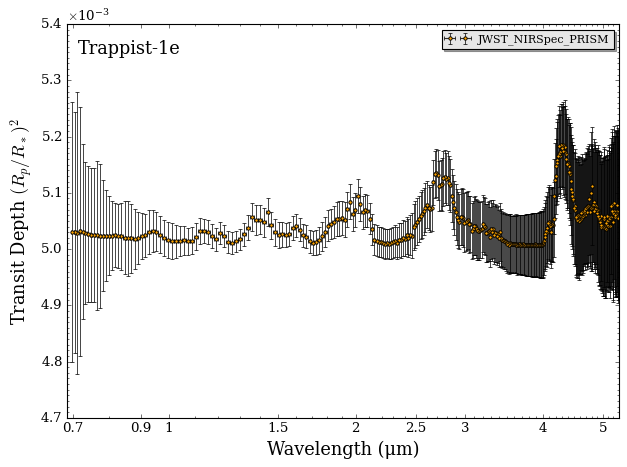

In [36]:
from POSEIDON.core import load_data, wl_grid_constant_R
from POSEIDON.visuals import plot_data


observation_file = OBSERVATION_FILE_RECON
data_dir = str(OBS_DIR)
datasets = [observation_file]
instruments = ["JWST_NIRSpec_PRISM"]

wl_min = 0.4
wl_max = 6.0
R_grid = 4000

wl_model = wl_grid_constant_R(wl_min, wl_max, R_grid)
data = load_data(data_dir, datasets, instruments, wl_model)

fig_data = plot_data(data, planet_name)


In [37]:
from POSEIDON.core import define_model, set_priors


model_name = MODEL_NAME
bulk_species = ["N2"]
param_species = ["H2O", "CH4", "CO2", "O3"]

model = define_model(
    model_name,
    bulk_species,
    param_species,
    PT_profile="isotherm",
    cloud_model="cloud-free",
)

print("Free parameters:", model["param_names"])

prior_types = {
    "T": "uniform",
    "R_p_ref": "uniform",
    "log_H2O": "uniform",
    "log_CH4": "uniform",
    "log_CO2": "uniform",
    "log_O3": "uniform",
}

prior_ranges = {
    "T": [200, 400],
    "R_p_ref": [0.85 * R_p, 1.15 * R_p],
    "log_H2O": [-8, -1],
    "log_CH4": [-8, -1],
    "log_CO2": [-5, -1],
    "log_O3": [-8, -1],
}

priors = set_priors(planet, star, model, data, prior_types, prior_ranges)


Free parameters: ['R_p_ref' 'T' 'log_H2O' 'log_CH4' 'log_CO2' 'log_O3']


In [17]:
from POSEIDON.core import read_opacities


opacity_treatment = "opacity_sampling"

T_fine = np.arange(200, 401, 10)
log_P_fine = np.arange(-2, 2.0001, 0.2)

opac = read_opacities(model, wl_model, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
H2O done
CH4 done
CO2 done
O3 done
Opacity pre-interpolation complete.


Generating corner plot ...


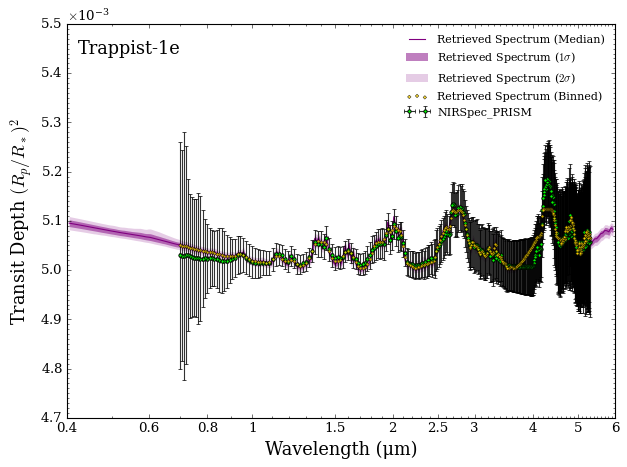

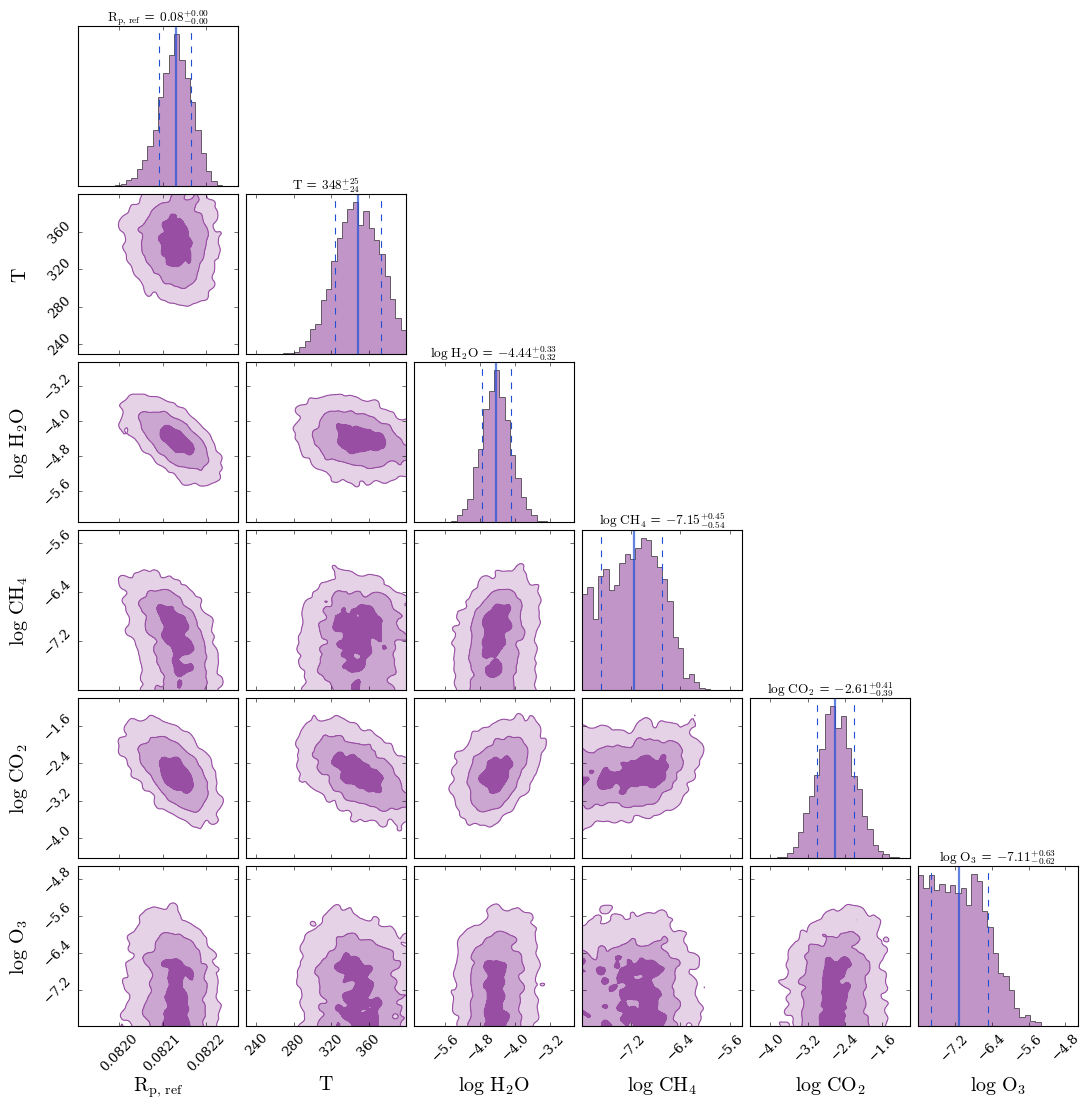

In [38]:
from POSEIDON.utility import read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_spectra_retrieved
from POSEIDON.corner import generate_cornerplot


wl_out, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(
    planet_name, model_name
)

spectra_median = plot_collection(spec_median, wl_out, collection=[])
spectra_low1 = plot_collection(spec_low1, wl_out, collection=[])
spectra_low2 = plot_collection(spec_low2, wl_out, collection=[])
spectra_high1 = plot_collection(spec_high1, wl_out, collection=[])
spectra_high2 = plot_collection(spec_high2, wl_out, collection=[])

fig_spec = plot_spectra_retrieved(
    spectra_median,
    spectra_low2,
    spectra_low1,
    spectra_high1,
    spectra_high2,
    planet_name,
    data,
    R_to_bin=100,
    data_labels=["NIRSpec_PRISM"],
    data_colour_list=["lime"],
)

fig_corner = generate_cornerplot(planet, model)


## Metrics vs clean truth (explicit averaging on the observed bins)

For this G-DAE branch, the final comparison is done by averaging both spectra directly over the observed wavelength bins `(wl_data, half_bin)`.
This is more robust here because the `*_recon.dat` products are stored in descending wavelength order, which can make the final bookkeeping step hard to interpret when everything is delegated to a black-box binning helper.

Then we compute:
- MSE between the retrieved median spectrum and the clean truth, both averaged over the observed bins.
- Reduced χ² using the observational errors.

Important:
- `N_FREE_PARAMS` must match the retrieval free-parameter count for a meaningful reduced χ².


In [39]:
from pathlib import Path

import numpy as np
import pandas as pd
from POSEIDON.utility import read_data


N_FREE_PARAMS = 11
LOG_PATH = COMMON_LOG_PATH
METRICS_BASIS = "median_retrieved_spectrum"


def band_average_to_bins(
    wl_src: np.ndarray,
    y_src: np.ndarray,
    centers: np.ndarray,
    halfwidths: np.ndarray,
    nsamp: int = 256,
) -> np.ndarray:
    """
    Average a spectrum over explicit wavelength bins using linear interpolation
    and trapezoidal integration.
    """
    wl_src = np.asarray(wl_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    centers = np.asarray(centers, dtype=float)
    halfwidths = np.asarray(halfwidths, dtype=float)

    sort_idx = np.argsort(wl_src)
    wl_sorted = wl_src[sort_idx]
    y_sorted = y_src[sort_idx]

    out = np.empty_like(centers, dtype=float)
    for i, (center, halfwidth) in enumerate(zip(centers, halfwidths)):
        a = center - halfwidth
        b = center + halfwidth
        x = np.linspace(a, b, nsamp)
        y = np.interp(x, wl_sorted, y_sorted)
        out[i] = np.trapz(y, x) / (b - a)

    return out


def append_metrics_to_csv(log_path: Path, row: dict) -> pd.DataFrame:
    """Append one metrics row using a fixed column order."""
    columns = [
        "planet_name",
        "model_name",
        "observation",
        "retrieval_strategy",
        "metrics_basis",
        "N",
        "p",
        "dof",
        "MSE",
        "rmse",
        "rmse_ppm",
        "chi2",
        "chi2_reduced",
    ]

    new_row_df = pd.DataFrame([row], columns=columns)

    if log_path.exists():
        df_log = pd.read_csv(log_path)
        for col in columns:
            if col not in df_log.columns:
                df_log[col] = np.nan
        df_log = df_log[columns]
        df_log = pd.concat([df_log, new_row_df], ignore_index=True)
    else:
        df_log = new_row_df

    df_log.to_csv(log_path, index=False, float_format="%.10g")
    print(f"Appended row to: {log_path.resolve()}")
    return df_log


# Load clean truth
wl_clean, y_clean = load_clean_spectrum(clean_path=CLEAN_PATH)

# Observed dataset grid + uncertainties
wl_data, half_bin, y_obs, err_obs = read_data(data_dir, observation_file)

# Sort the observed vectors for plotting and explicit bin averaging
sort_idx = np.argsort(np.asarray(wl_data, dtype=float))
wl_data = np.asarray(wl_data, dtype=float)[sort_idx]
half_bin = np.asarray(half_bin, dtype=float)[sort_idx]
y_obs = np.asarray(y_obs, dtype=float)[sort_idx]
err_obs = np.asarray(err_obs, dtype=float)[sort_idx]

# Average both spectra directly on the observed bins
model_binned = band_average_to_bins(wl_out, spec_median, wl_data, half_bin)
clean_binned = band_average_to_bins(wl_clean, y_clean, wl_data, half_bin)

if not (len(model_binned) == len(clean_binned) == len(err_obs)):
    raise ValueError("Binned arrays and errors must have the same length.")

sig = np.asarray(err_obs, dtype=float)
if np.any(sig <= 0):
    raise ValueError("Found non-positive uncertainties in err_obs; χ² is not valid.")

resid = np.asarray(model_binned, dtype=float) - np.asarray(clean_binned, dtype=float)

N = int(resid.size)
p = int(N_FREE_PARAMS)
dof = int(max(N - p, 0))

chi2 = float(np.sum((resid / sig) ** 2))
chi2_reduced = chi2 / dof if dof > 0 else np.nan

mse = float(np.mean(resid**2))
rmse = float(np.sqrt(mse))
rmse_ppm = float(1e6 * rmse)

print("---- Metrics vs clean truth (no mask) ----")
print(f"N points      : {N}")
print(f"Free params p : {p}")
print(f"DoF           : {dof}")
print(f"MSE           : {mse:.6e}")
print(f"RMSE          : {rmse:.6e} ({rmse_ppm:.2f} ppm)")
print(f"chi2          : {chi2:.6f}")
print(f"chi2_reduced  : {chi2_reduced:.6f}")

row = {
    "planet_name": planet_name,
    "model_name": model_name,
    "observation": observation_file,
    "retrieval_strategy": RETRIEVAL_STRATEGY,
    "metrics_basis": METRICS_BASIS,
    "N": N,
    "p": p,
    "dof": dof,
    "MSE": mse,
    "rmse": rmse,
    "rmse_ppm": rmse_ppm,
    "chi2": chi2,
    "chi2_reduced": chi2_reduced,
}

df_log = append_metrics_to_csv(LOG_PATH, row)


---- Metrics vs clean truth (no mask) ----
N points      : 385
Free params p : 11
DoF           : 374
MSE           : 6.435394e-10
RMSE          : 2.536808e-05 (25.37 ppm)
chi2          : 95.768054
chi2_reduced  : 0.256064
Appended row to: /mnt/c/Proyectos/Astro/gdaespec/Earth_like_Atmosphere/Retrieval Tests/sphinx_injection/chi2_log_sphinx.csv
